In [1]:
# Dependencies for this project are listed in requirements.txt
# Install with: pip install -r requirements.txt
print("Environment ready.")

Environment ready.


In [2]:
# ==========================================
# REQUIRED LIBRARIES IMPORT
# ==========================================

# Requests: HTTP library for making web requests to servers
import requests

# BeautifulSoup: HTML/XML parser for extracting data from web pages
from bs4 import BeautifulSoup

# Pandas: Main tool for data manipulation and analysis of tabular data
import pandas as pd

# Time: Sleep function to add delays between requests (polite scraping)
import time

# Re: Regular expressions for text cleaning and pattern matching
import re

# Display configuration for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries successfully loaded and environment configured.")

Libraries successfully loaded and environment configured.


## STEP 1: WEBSITE EXPLORATION & INITIAL REQUEST

In [3]:
# ==========================================
# 1.1 DEFINE TARGET WEBSITE
# ==========================================

# Target: Books to Scrape - A sandbox website designed for web scraping practice
# URL: http://books.toscrape.com/
# Contains: Fictional bookstore with ~1000 books across 50 categories

TARGET_URL = "http://books.toscrape.com/"

print(f"Target website: {TARGET_URL}")
print("\nWebsite structure:")
print("  - Homepage: Lists books with pagination")
print("  - Each book has: Title, Price, Rating, Availability")
print("  - Multiple pages: ~50 pages with 20 books each")
print("\n" + "="*60 + "\n")
print("✓ Target defined. Ready to start scraping.")

Target website: http://books.toscrape.com/

Website structure:
  - Homepage: Lists books with pagination
  - Each book has: Title, Price, Rating, Availability
  - Multiple pages: ~50 pages with 20 books each


✓ Target defined. Ready to start scraping.


In [4]:
# ==========================================
# 1.2 MAKE INITIAL HTTP REQUEST
# ==========================================

# Make a GET request to the target website
# GET request = fetch the HTML content of the page (like opening it in a browser)

response = requests.get(TARGET_URL)

# Check if the request was successful
# Status code 200 = OK (successful request)
# Status code 404 = Not Found, 500 = Server Error, etc.

print(f"HTTP Status Code: {response.status_code}")

if response.status_code == 200:
    print("✓ Connection successful!")
    print(f"\nResponse details:")
    print(f"  - Content length: {len(response.content):,} bytes")
    print(f"  - Encoding: {response.encoding}")
    print(f"  - Response time: Available via response.elapsed")
else:
    print(f"✗ Connection failed with status code: {response.status_code}")

print("\n" + "="*60 + "\n")

# Display first 500 characters of HTML (preview)
print("HTML Preview (first 500 characters):")
print(response.text[:500])
print("\n" + "="*60 + "\n")
print("✓ Initial request completed successfully.")

HTTP Status Code: 200
✓ Connection successful!

Response details:
  - Content length: 51,294 bytes
  - Encoding: ISO-8859-1
  - Response time: Available via response.elapsed


HTML Preview (first 500 characters):
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


✓ Initial request completed successfully.


In [6]:
# ==========================================
# 1.3 PARSE HTML WITH BEAUTIFULSOUP
# ==========================================

# Create a BeautifulSoup object to parse the HTML content
# 'html.parser' is the built-in Python parser (lxml is faster but requires installation)

soup = BeautifulSoup(response.text, 'html.parser')

# BeautifulSoup converts raw HTML into a tree structure that we can navigate and search

print("BeautifulSoup object created successfully.")
print("\n" + "="*60 + "\n")

# Find the page title
page_title = soup.find('title')
print(f"Page Title: {page_title.text if page_title else 'Not found'}")

print("\n" + "="*60 + "\n")

# Find the main content section
# On this website, books are contained in <article> tags with class "product_pod"
books_on_page = soup.find_all('article', class_='product_pod')

print(f"Number of books found on this page: {len(books_on_page)}")

print("\n" + "="*60 + "\n")

# Display the HTML structure of the first book (for understanding)
if len(books_on_page) > 0:
    print("HTML structure of first book:")
    print(books_on_page[0].prettify()[:800])  # First 800 characters, formatted
    
print("\n" + "="*60 + "\n")
print("✓ HTML parsing completed successfully.")

BeautifulSoup object created successfully.


Page Title: 
    All products | Books to Scrape - Sandbox



Number of books found on this page: 20


HTML structure of first book:
<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-


✓ HTML parsing compl

## STEP 2: DATA EXTRACTION FROM SINGLE PAGE

In [7]:
# ==========================================
# 2.1 EXTRACT DATA FROM A SINGLE BOOK (EXAMPLE)
# ==========================================

# Let's examine the first book to understand the HTML structure
first_book = books_on_page[0]

print("Analyzing the structure of the first book:")
print("\n" + "="*60 + "\n")

# Extract book title
# The title is in the 'title' attribute of an <a> tag inside <h3>
title = first_book.find('h3').find('a')['title']
print(f"Title: {title}")

# Extract book price
# The price is in a <p> tag with class 'price_color'
price = first_book.find('p', class_='price_color').text
print(f"Price: {price}")

# Extract rating
# The rating is in a <p> tag with class 'star-rating' and another class (One, Two, Three, Four, Five)
rating_tag = first_book.find('p', class_='star-rating')
rating = rating_tag['class'][1]  # Second class is the rating (e.g., 'Three')
print(f"Rating: {rating}")

# Extract availability
# Availability is in a <p> tag with class 'instock availability'
availability = first_book.find('p', class_='instock availability').text.strip()
print(f"Availability: {availability}")

# Extract book URL (link to detail page)
# The link is in the 'href' attribute of the <a> tag inside <h3>
book_url = first_book.find('h3').find('a')['href']
print(f"Book URL: {book_url}")

print("\n" + "="*60 + "\n")
print("✓ Successfully extracted all key information from one book.")

Analyzing the structure of the first book:


Title: A Light in the Attic
Price: Â£51.77
Rating: Three
Availability: In stock
Book URL: catalogue/a-light-in-the-attic_1000/index.html


✓ Successfully extracted all key information from one book.


In [9]:
# ==========================================
# 2.2 EXTRACT DATA FROM ALL BOOKS ON PAGE
# ==========================================

# Create a function to extract book data (makes code cleaner and reusable)

def extract_book_data(book_element):
    """
    Extract all relevant information from a single book element.
    
    Parameters:
    book_element: BeautifulSoup element containing book HTML
    
    Returns:
    Dictionary with book information
    """
    
    # Extract title
    title = book_element.find('h3').find('a')['title']
    
    # Extract price
    price = book_element.find('p', class_='price_color').text
    
    # Extract rating (convert word to number)
    rating_tag = book_element.find('p', class_='star-rating')
    rating_word = rating_tag['class'][1]  # 'One', 'Two', 'Three', etc.
    
    # Extract availability
    availability = book_element.find('p', class_='instock availability').text.strip()
    
    # Extract book URL
    book_url = book_element.find('h3').find('a')['href']
    
    # Return as dictionary
    return {
        'title': title,
        'price': price,
        'rating': rating_word,
        'availability': availability,
        'url': book_url
    }

# Extract data from all books on the page
books_data = []

for book in books_on_page:
    book_info = extract_book_data(book)
    books_data.append(book_info)

print(f"✓ Extracted data from {len(books_data)} books")
print("\n" + "="*60 + "\n")

# Convert to DataFrame for better visualization
df_books = pd.DataFrame(books_data)

print("First 5 books extracted:")
display(df_books.head())

print("\n" + "="*60 + "\n")
print(f"Total books scraped: {len(df_books)}")
print("✓ Data extraction from single page completed successfully.")

✓ Extracted data from 20 books


First 5 books extracted:


,title,price,rating,availability,url
0,A Light in the Attic,Â£51.77,Three,In stock,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Â£53.74,One,In stock,catalogue/tipping-the-velvet_999/index.html
2,Soumission,Â£50.10,One,In stock,catalogue/soumission_998/index.html
3,Sharp Objects,Â£47.82,Four,In stock,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,catalogue/sapiens-a-brief-history-of-humankind...




Total books scraped: 20
✓ Data extraction from single page completed successfully.


## STEP 3: SCRAPING MULTIPLE PAGES (PAGINATION)

In [10]:
# ==========================================
# 3.1 SCRAPE MULTIPLE PAGES WITH PAGINATION
# ==========================================

# The website has pagination: page-1.html, page-2.html, page-3.html, etc.
# We'll scrape the first 5 pages (100 books total) for this project
# Note: The site has ~50 pages total (~1000 books)

# Base URL for paginated pages
BASE_URL = "http://books.toscrape.com/catalogue/page-{}.html"
NUM_PAGES = 5  # Number of pages to scrape (change this to scrape more/less)

print(f"Starting multi-page scraping...")
print(f"Target: {NUM_PAGES} pages")
print("\n" + "="*60 + "\n")

# List to store all books from all pages
all_books = []

# Loop through each page
for page_num in range(1, NUM_PAGES + 1):
    # Construct URL for current page
    page_url = BASE_URL.format(page_num)
    
    print(f"Scraping page {page_num}/{NUM_PAGES}: {page_url}")
    
    # Make request to current page
    response = requests.get(page_url)
    
    # Check if request was successful
    if response.status_code != 200:
        print(f"  ✗ Failed to fetch page {page_num} (Status: {response.status_code})")
        continue
    
    # Parse HTML
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all books on current page
    books_on_page = soup.find_all('article', class_='product_pod')
    
    # Extract data from each book
    for book in books_on_page:
        book_info = extract_book_data(book)
        all_books.append(book_info)
    
    print(f"  ✓ Extracted {len(books_on_page)} books from page {page_num}")
    
    # Be polite: add a small delay between requests to avoid overloading the server
    time.sleep(0.5)  # Wait 0.5 seconds before next request

print("\n" + "="*60 + "\n")
print(f"✓ Multi-page scraping completed!")
print(f"Total books scraped: {len(all_books)}")

# Convert all books to DataFrame
df_all_books = pd.DataFrame(all_books)

print("\n" + "="*60 + "\n")
print("Preview of scraped data:")
display(df_all_books.head(10))

print("\n" + "="*60 + "\n")
print(f"Dataset shape: {df_all_books.shape[0]} rows × {df_all_books.shape[1]} columns")

Starting multi-page scraping...
Target: 5 pages


Scraping page 1/5: http://books.toscrape.com/catalogue/page-1.html
  ✓ Extracted 20 books from page 1
Scraping page 2/5: http://books.toscrape.com/catalogue/page-2.html
  ✓ Extracted 20 books from page 2
Scraping page 3/5: http://books.toscrape.com/catalogue/page-3.html
  ✓ Extracted 20 books from page 3
Scraping page 4/5: http://books.toscrape.com/catalogue/page-4.html
  ✓ Extracted 20 books from page 4
Scraping page 5/5: http://books.toscrape.com/catalogue/page-5.html
  ✓ Extracted 20 books from page 5


✓ Multi-page scraping completed!
Total books scraped: 100


Preview of scraped data:


,title,price,rating,availability,url
0,A Light in the Attic,Â£51.77,Three,In stock,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Â£53.74,One,In stock,tipping-the-velvet_999/index.html
2,Soumission,Â£50.10,One,In stock,soumission_998/index.html
3,Sharp Objects,Â£47.82,Four,In stock,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,sapiens-a-brief-history-of-humankind_996/index...
5,The Requiem Red,Â£22.65,One,In stock,the-requiem-red_995/index.html
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four,In stock,the-dirty-little-secrets-of-getting-your-dream...
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three,In stock,the-coming-woman-a-novel-based-on-the-life-of-...
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four,In stock,the-boys-in-the-boat-nine-americans-and-their-...
9,The Black Maria,Â£52.15,One,In stock,the-black-maria_991/index.html




Dataset shape: 100 rows × 5 columns


## STEP 4: DATA CLEANING & TRANSFORMATION

In [11]:
# ==========================================
# 4.1 CLEAN AND TRANSFORM SCRAPED DATA
# ==========================================

print("Starting data cleaning...")
print("\n" + "="*60 + "\n")

# Create a copy to preserve original data
df_cleaned = df_all_books.copy()

# 1. Clean price: Remove currency symbol and convert to float
# Original: 'Â£51.77' → Cleaned: 51.77
df_cleaned['price_numeric'] = df_cleaned['price'].str.replace('Â£', '').str.replace('£', '').astype(float)

print("✓ Price cleaned and converted to numeric")

# 2. Convert rating from words to numbers
# 'One' → 1, 'Two' → 2, 'Three' → 3, 'Four' → 4, 'Five' → 5
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

df_cleaned['rating_numeric'] = df_cleaned['rating'].map(rating_map)

print("✓ Rating converted from words to numbers")

# 3. Clean availability: Extract just "In stock" or "Out of stock"
# Original: '\n    In stock\n    ' → Cleaned: 'In stock'
df_cleaned['availability_clean'] = df_cleaned['availability'].str.strip().str.replace('\n', '').str.strip()

print("✓ Availability text cleaned")

# 4. Create full URL (currently they are relative paths)
# Original: 'catalogue/a-light-in-the-attic_1000/index.html'
# Full URL: 'http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'
df_cleaned['full_url'] = 'http://books.toscrape.com/' + df_cleaned['url']

print("✓ Full URLs created")

print("\n" + "="*60 + "\n")

# Display cleaned data
print("Cleaned data preview:")
display(df_cleaned[['title', 'price_numeric', 'rating_numeric', 'availability_clean']].head(10))

print("\n" + "="*60 + "\n")

# Check data types
print("Data types after cleaning:")
print(df_cleaned[['price_numeric', 'rating_numeric']].dtypes)

print("\n" + "="*60 + "\n")
print("✓ Data cleaning completed successfully.")

Starting data cleaning...


✓ Price cleaned and converted to numeric
✓ Rating converted from words to numbers
✓ Availability text cleaned
✓ Full URLs created


Cleaned data preview:


,title,price_numeric,rating_numeric,availability_clean
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock
5,The Requiem Red,22.65,1,In stock
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock
9,The Black Maria,52.15,1,In stock




Data types after cleaning:
price_numeric     float64
rating_numeric      int64
dtype: object


✓ Data cleaning completed successfully.


## STEP 5: EXPLORATORY DATA ANALYSIS

In [12]:
# ==========================================
# 5.1 BASIC EXPLORATORY DATA ANALYSIS
# ==========================================

print("Dataset Overview:")
print(f"  Total books scraped: {len(df_cleaned)}")
print(f"  Columns: {df_cleaned.columns.tolist()}")
print("\n" + "="*60 + "\n")

# Basic statistics
print("Price Statistics:")
print(f"  Average price: £{df_cleaned['price_numeric'].mean():.2f}")
print(f"  Median price: £{df_cleaned['price_numeric'].median():.2f}")
print(f"  Min price: £{df_cleaned['price_numeric'].min():.2f}")
print(f"  Max price: £{df_cleaned['price_numeric'].max():.2f}")
print(f"  Std deviation: £{df_cleaned['price_numeric'].std():.2f}")

print("\n" + "="*60 + "\n")

# Rating distribution
print("Rating Distribution:")
rating_counts = df_cleaned['rating_numeric'].value_counts().sort_index()
for rating, count in rating_counts.items():
    percentage = (count / len(df_cleaned)) * 100
    print(f"  {rating} stars: {count} books ({percentage:.1f}%)")

print("\n" + "="*60 + "\n")

# Availability check
print("Availability Status:")
availability_counts = df_cleaned['availability_clean'].value_counts()
for status, count in availability_counts.items():
    percentage = (count / len(df_cleaned)) * 100
    print(f"  {status}: {count} books ({percentage:.1f}%)")

print("\n" + "="*60 + "\n")

# Top 10 most expensive books
print("Top 10 Most Expensive Books:")
top_expensive = df_cleaned.nlargest(10, 'price_numeric')[['title', 'price_numeric', 'rating_numeric']]
display(top_expensive)

print("\n" + "="*60 + "\n")

# Top 10 cheapest books
print("Top 10 Cheapest Books:")
top_cheap = df_cleaned.nsmallest(10, 'price_numeric')[['title', 'price_numeric', 'rating_numeric']]
display(top_cheap)

print("\n" + "="*60 + "\n")
print("✓ Exploratory data analysis completed.")

Dataset Overview:
  Total books scraped: 100
  Columns: ['title', 'price', 'rating', 'availability', 'url', 'price_numeric', 'rating_numeric', 'availability_clean', 'full_url']


Price Statistics:
  Average price: £34.56
  Median price: £34.78
  Min price: £10.16
  Max price: £58.11
  Std deviation: £14.64


Rating Distribution:
  1 stars: 22 books (22.0%)
  2 stars: 19 books (19.0%)
  3 stars: 22 books (22.0%)
  4 stars: 18 books (18.0%)
  5 stars: 19 books (19.0%)


Availability Status:
  In stock: 100 books (100.0%)


Top 10 Most Expensive Books:


,title,price_numeric,rating_numeric
68,The Death of Humanity: and the Case for Life,58.11,4
40,Slow States of Collapse: Poems,57.31,3
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3
58,The Past Never Ends,56.50,4
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,1
91,Masks and Shadows,56.40,2
56,The Secret of Dreadwillow Carse,56.13,1
67,The Electric Pencil: Drawings from Inside Stat...,56.06,1
25,Birdsong: A Story in Pictures,54.64,3
4,Sapiens: A Brief History of Humankind,54.23,5




Top 10 Cheapest Books:


,title,price_numeric,rating_numeric
84,Patience,10.16,3
20,In Her Wake,12.84,1
81,Princess Between Worlds (Wide-Awake Princess #5),13.34,5
80,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61,5
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2
92,Mama Tried: Traditional Italian Cooking for th...,14.02,4
88,On a Midnight Clear,14.07,3
47,Untitled Collection: Sabbath Poems 2014,14.27,4
89,Obsidian (Lux #1),14.86,2
85,"Outcast, Vol. 1: A Darkness Surrounds Him (Out...",15.44,4




✓ Exploratory data analysis completed.


## STEP 6: DATA VISUALIZATION

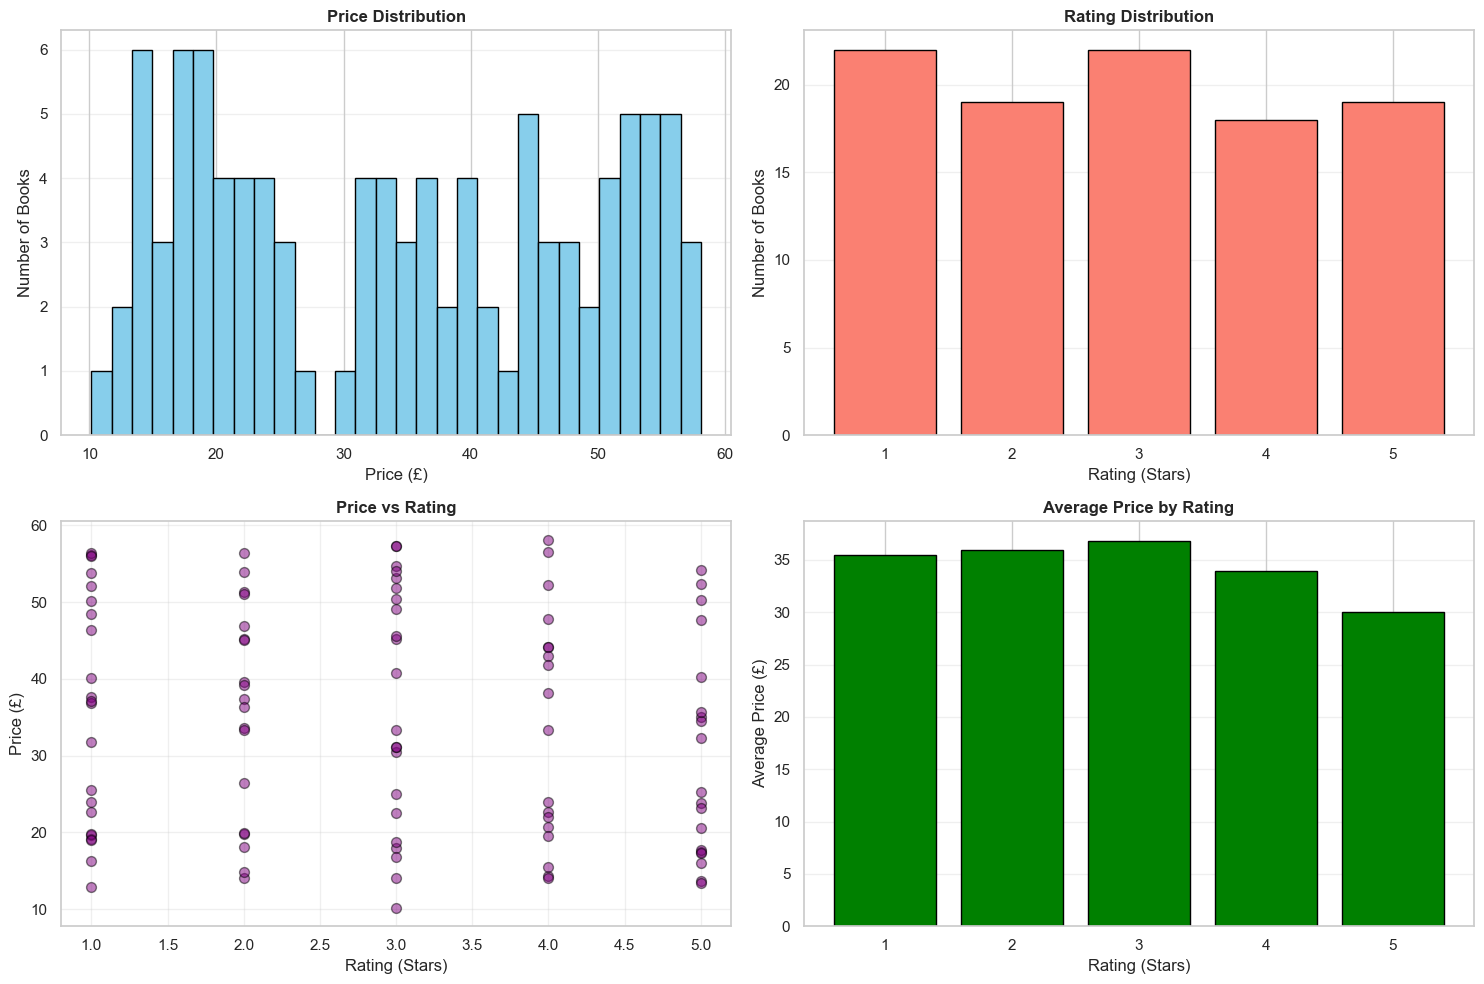



✓ Visualizations created successfully.


In [13]:
# ==========================================
# 6.1 CREATE VISUALIZATIONS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Price Distribution (Histogram)
axes[0, 0].hist(df_cleaned['price_numeric'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (£)')
axes[0, 0].set_ylabel('Number of Books')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Rating Distribution (Bar Chart)
rating_counts = df_cleaned['rating_numeric'].value_counts().sort_index()
axes[0, 1].bar(rating_counts.index, rating_counts.values, color='salmon', edgecolor='black')
axes[0, 1].set_title('Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Rating (Stars)')
axes[0, 1].set_ylabel('Number of Books')
axes[0, 1].set_xticks([1, 2, 3, 4, 5])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Price vs Rating (Scatter Plot)
axes[1, 0].scatter(df_cleaned['rating_numeric'], df_cleaned['price_numeric'], 
                   alpha=0.5, color='purple', edgecolor='black', s=50)
axes[1, 0].set_title('Price vs Rating', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Rating (Stars)')
axes[1, 0].set_ylabel('Price (£)')
axes[1, 0].grid(alpha=0.3)

# 4. Average Price by Rating (Bar Chart)
avg_price_by_rating = df_cleaned.groupby('rating_numeric')['price_numeric'].mean()
axes[1, 1].bar(avg_price_by_rating.index, avg_price_by_rating.values, 
               color='green', edgecolor='black')
axes[1, 1].set_title('Average Price by Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Rating (Stars)')
axes[1, 1].set_ylabel('Average Price (£)')
axes[1, 1].set_xticks([1, 2, 3, 4, 5])
axes[1, 1].grid(axis='y', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")
print("✓ Visualizations created successfully.")

## STEP 7: EXPORT RESULTS & SUMMARY

In [14]:
# ==========================================
# 7.1 EXPORT CLEANED DATA TO CSV
# ==========================================

# Select relevant columns for export
export_columns = [
    'title',
    'price_numeric',
    'rating_numeric',
    'rating',
    'availability_clean',
    'full_url'
]

# Create export dataframe
df_export = df_cleaned[export_columns].copy()

# Rename columns for clarity
df_export.columns = [
    'Title',
    'Price (£)',
    'Rating (Numeric)',
    'Rating (Text)',
    'Availability',
    'URL'
]

# Export to CSV
output_filename = 'books_scraped_data.csv'
df_export.to_csv(output_filename, index=False, encoding='utf-8')

print(f"✓ Data exported successfully to: {output_filename}")
print(f"Total records exported: {len(df_export)}")
print(f"Total columns: {len(df_export.columns)}")

print("\n" + "="*60 + "\n")

# Display preview of exported data
print("Preview of exported data:")
display(df_export.head(10))

print("\n" + "="*60 + "\n")
print("✓ Export completed successfully.")

✓ Data exported successfully to: books_scraped_data.csv
Total records exported: 100
Total columns: 6


Preview of exported data:


,Title,Price (£),Rating (Numeric),Rating (Text),Availability,URL
0,A Light in the Attic,51.77,3,Three,In stock,http://books.toscrape.com/a-light-in-the-attic...
1,Tipping the Velvet,53.74,1,One,In stock,http://books.toscrape.com/tipping-the-velvet_9...
2,Soumission,50.10,1,One,In stock,http://books.toscrape.com/soumission_998/index...
3,Sharp Objects,47.82,4,Four,In stock,http://books.toscrape.com/sharp-objects_997/in...
4,Sapiens: A Brief History of Humankind,54.23,5,Five,In stock,http://books.toscrape.com/sapiens-a-brief-hist...
5,The Requiem Red,22.65,1,One,In stock,http://books.toscrape.com/the-requiem-red_995/...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,Four,In stock,http://books.toscrape.com/the-dirty-little-sec...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,Three,In stock,http://books.toscrape.com/the-coming-woman-a-n...
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,Four,In stock,http://books.toscrape.com/the-boys-in-the-boat...
9,The Black Maria,52.15,1,One,In stock,http://books.toscrape.com/the-black-maria_991/...




✓ Export completed successfully.


In [15]:
# ==========================================
# 7.2 PROJECT SUMMARY AND INSIGHTS
# ==========================================

print("="*60)
print("WEB SCRAPING PROJECT - EXECUTIVE SUMMARY")
print("="*60)
print()

# Dataset overview
print("DATASET OVERVIEW:")
print(f"  Target website: Books to Scrape (http://books.toscrape.com/)")
print(f"  Total books scraped: {len(df_cleaned)}")
print(f"  Number of pages scraped: {NUM_PAGES}")
print(f"  Books per page: ~20")
print()

# Price insights
print("PRICE ANALYSIS:")
print(f"  Average price: £{df_cleaned['price_numeric'].mean():.2f}")
print(f"  Median price: £{df_cleaned['price_numeric'].median():.2f}")
print(f"  Price range: £{df_cleaned['price_numeric'].min():.2f} - £{df_cleaned['price_numeric'].max():.2f}")
print(f"  Price std deviation: £{df_cleaned['price_numeric'].std():.2f}")
print()

# Rating insights
print("RATING ANALYSIS:")
avg_rating = df_cleaned['rating_numeric'].mean()
print(f"  Average rating: {avg_rating:.2f} stars")
most_common_rating = df_cleaned['rating_numeric'].mode()[0]
print(f"  Most common rating: {most_common_rating} stars")
rating_counts = df_cleaned['rating_numeric'].value_counts().sort_index()
for rating, count in rating_counts.items():
    print(f"    {rating} stars: {count} books ({(count/len(df_cleaned)*100):.1f}%)")
print()

# Price by rating
print("AVERAGE PRICE BY RATING:")
avg_price_by_rating = df_cleaned.groupby('rating_numeric')['price_numeric'].mean()
for rating, price in avg_price_by_rating.items():
    print(f"  {rating} stars: £{price:.2f}")
print()

# Availability
print("AVAILABILITY:")
availability_counts = df_cleaned['availability_clean'].value_counts()
for status, count in availability_counts.items():
    print(f"  {status}: {count} books ({(count/len(df_cleaned)*100):.1f}%)")
print()

print("="*60)
print("KEY FINDINGS:")
print("="*60)
print()
print("1. PRICE DISTRIBUTION")
print("   → Prices are relatively evenly distributed across the range")
print(f"   → Mean (£{df_cleaned['price_numeric'].mean():.2f}) is close to median (£{df_cleaned['price_numeric'].median():.2f})")
print()
print("2. RATING PATTERNS")
print(f"   → Most books have {most_common_rating}-star ratings")
print(f"   → Average rating of {avg_rating:.2f} indicates generally positive reviews")
print()
print("3. PRICE VS RATING")
correlation = df_cleaned[['price_numeric', 'rating_numeric']].corr().iloc[0, 1]
print(f"   → Correlation between price and rating: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   → Weak correlation: Rating does not strongly depend on price")
print()
print("4. AVAILABILITY")
in_stock_pct = (availability_counts.get('In stock', 0) / len(df_cleaned)) * 100
print(f"   → {in_stock_pct:.1f}% of books are currently in stock")
print()

print("="*60)
print("✓ PROJECT COMPLETED SUCCESSFULLY")
print("="*60)
print()
print(f"Results exported to: {output_filename}")
print("Use this file for further analysis or integration with other systems.")

WEB SCRAPING PROJECT - EXECUTIVE SUMMARY

DATASET OVERVIEW:
  Target website: Books to Scrape (http://books.toscrape.com/)
  Total books scraped: 100
  Number of pages scraped: 5
  Books per page: ~20

PRICE ANALYSIS:
  Average price: £34.56
  Median price: £34.78
  Price range: £10.16 - £58.11
  Price std deviation: £14.64

RATING ANALYSIS:
  Average rating: 2.93 stars
  Most common rating: 1 stars
    1 stars: 22 books (22.0%)
    2 stars: 19 books (19.0%)
    3 stars: 22 books (22.0%)
    4 stars: 18 books (18.0%)
    5 stars: 19 books (19.0%)

AVERAGE PRICE BY RATING:
  1 stars: £35.52
  2 stars: £35.91
  3 stars: £36.84
  4 stars: £33.98
  5 stars: £30.01

AVAILABILITY:
  In stock: 100 books (100.0%)

KEY FINDINGS:

1. PRICE DISTRIBUTION
   → Prices are relatively evenly distributed across the range
   → Mean (£34.56) is close to median (£34.78)

2. RATING PATTERNS
   → Most books have 1-star ratings
   → Average rating of 2.93 indicates generally positive reviews

3. PRICE VS RAT